## Overview
This notebook evaluates OpenDP-Tumult on TPC-H queries (Q13, Q16) under different privacy/suppression policies. It loads truth CSVs and DP run outputs, computes per-run errors (absolute and relative), aggregates results, saves summaries, and produces box/bar plots.

In [2]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["SPARK_HOME"] = "/Users/kinchintong/project/tumult-labs/spark-4.0.1-bin-hadoop3"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
findspark.init(os.environ["SPARK_HOME"])
from math import floor
from pyspark import SparkFiles
from pyspark.sql import SparkSession, types as T, functions as F
from tmlt.analytics.privacy_budget import PureDPBudget
from tmlt.analytics.protected_change import (AddOneRow, AddMaxRows, AddRowsWithID)
from tmlt.analytics.query_builder import QueryBuilder
from tmlt.analytics.session import Session, ColumnType
from tmlt.analytics.keyset import KeySet
from functools import reduce
from tmlt.analytics import (
    AddOneRow,
    PureDPBudget,
    QueryBuilder,
    Session,
    AddRowsWithID,
    GroupbyCountQuery,
)

from tmlt.analytics.truncation_strategy import TruncationStrategy

# Silence some Spark warnings
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ResourceWarning)

findspark.init()

# Set up Spark
spark = (
    SparkSession.builder
    .appName("tpch-setup")
    .master("local[*]")           # drop if connecting to a cluster
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("ERROR")

spark.conf.set("spark.sql.session.timeZone", "UTC")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/11 21:27:57 WARN Utils: Your hostname, kinchins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.184 instead (on interface en0)
26/01/11 21:27:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/11 21:27:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/11 21:27:57 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1


***
## Calcuate Error

In [3]:
from typing import List
import matplotlib.pyplot as plt
import pandas as pd

def compute_errors_privatesql_style(
    dp_df,
    truth_df,
    keys: List[str],
    metric: str = "count_order",
    run_col: str = "run_id",
    join_type: str = "left",
    truth_missing_as_zero: bool = False,
):
    """
    Compute PrivateSQL-style errors per output group per run.
      Qerror(y, y~)   = |y - y~|
      RelError(y, y~) = |y - y~| / max(50, y)

    Returns columns:
      run_id,
      keys,
      <metric>_truth,
      <metric>_dp,
      qerror_<metric>,
      relerror_<metric>
    """

    # Prepare DP side
    dp = (
        dp_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_dp")
    )
    

    # Prepare truth side
    tr = (
        truth_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_truth")
    )
    #print("The Truth")
    #tr.show()
    #print("DP")
    #dp.where("run_id==1").select("*").show()

    joined = dp.alias("dp").join(tr.alias("tr"), on=keys, how=join_type)
    print("join")
    if truth_missing_as_zero:
        joined = joined.withColumn(
            f"{metric}_truth",
            F.coalesce(F.col(f"{metric}_truth"), F.lit(0.0))
        )

    #print("truth_missing_as_zero")
    #joined.where("run_id==1").select("*").show()

    # Absolute error |y - y~|
    joined = joined.withColumn(
        f"qerror",
        F.abs(F.col(f"{metric}_truth") - F.col(f"{metric}_dp"))
    )

    print("qerror")
    joined.where("run_id==1").select("*").show()

    # Relative error |y - y~| / max(50, y)
    joined = joined.withColumn(
        f"relerror",
        F.col(f"qerror") /
        F.greatest(F.lit(1.0), F.col(f"{metric}_truth"))
    )

    print("relerror")
    joined.where("run_id==1").select("*").show()

    ret = joined.select(
        run_col,
        *keys,
        f"{metric}_truth",
        f"{metric}_dp",
        f"qerror",
        f"relerror",
    )
    return ret

tpch_query_results = {}


In [4]:
def q1_calculate_errors(test_profile: str, test_case: str):
    try:
        # -------------------------
        # CONFIG
        # -------------------------
        keys = ["l_returnflag", "l_linestatus"]
        metrics = "count_order"
        metric_casts = {"count_order": "long"}  # important: count is integer

        eps_val = 1
        truth_path = "./output/no_dp/q1_result_csv"

        # -------------------------
        # LOAD TRUTH
        # -------------------------
        truth = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(truth_path)
            .select(*keys, "count_order")
            .withColumn(metrics, F.col(metrics).cast("long"))
        )

        # -------------------------
        # LOAD RUNS (ALL 1000)
        # -------------------------
        runs_glob = f"./output/{test_profile}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"
        dp_runs = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(runs_glob)
            .withColumn(
                "run_id",
                F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
            )
            .select("run_id", *keys, metrics)
            .withColumn(metrics, F.col(metrics).cast("long"))
        )
        print("Q1")
        print("Distinct runs =", dp_runs.select("run_id").distinct().count())

        err_df = compute_errors_privatesql_style(
            dp_df=dp_runs,
            truth_df=truth,
            keys=keys,
            metric=metrics,
            run_col="run_id",
            join_type="left",
            truth_missing_as_zero=True,
        )
        print("----------")
        err_df.show()

        tmperr_df = err_df.where("l_returnflag='A' and l_linestatus='F'")
        tmperr_df.show()

        print("----------")

        per_run = tmperr_df.groupBy("run_id").agg(
            F.avg("qerror").alias("avg_qerror_per_run"),
            F.avg("relerror").alias("avg_relerror_per_run"),
            F.count("relerror").alias("num_groups_per_run")
        ).orderBy("run_id")

        per_run.show()

        relerror = (
            per_run
            .select("avg_relerror_per_run")
            .dropna()
            .toPandas()
        )

        qerror = (
            per_run
            .select("avg_qerror_per_run")
            .dropna()
            .toPandas()
        )

        overall = per_run.agg(
            F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
            F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
        )

        result ={
                "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
                "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
                "qerror": qerror,
                "relerror": relerror
            }

        '''plt.figure(figsize=(4, 4))
        plt.boxplot(relerror, showfliers=False)
        plt.xticks([1], ["Q1"])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("relerror Distribution (Q1)")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(4, 4))
        plt.boxplot(qerror, showfliers=False)
        plt.xticks([1], ["Q1"])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("qerror Distribution (Q1)")
        plt.tight_layout()
        plt.show()'''
        return result
    except Exception as e:
        print("Error in q1_calculate_errors:", e)
        return {}

In [5]:
def q4_calculate_errors(test_profile: str, test_case: str):
    try:

        # -------------------------
        # CONFIG
        # -------------------------
        keys = ["o_orderpriority"]
        metrics = "order_count"

        eps_val = 1
        truth_path = "./output/no_dp/q4_result_csv"
        # -------------------------
        # LOAD TRUTH
        # -------------------------
        truth = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(truth_path)
            .select(*keys, "order_count")
            .withColumn("order_count", F.col("order_count").cast("long"))
        )

        # -------------------------
        # LOAD RUNS (ALL 1000)
        # -------------------------
        runs_glob = f"./output/{test_profile}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

        dp_runs = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(runs_glob)
            .withColumn(
                "run_id",
                F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
            )
            .select("run_id", *keys, "order_count")
            .withColumn("order_count", F.col("order_count").cast("long"))
        )

        print(f"Q4 - {test_case}")
        print("Distinct runs =", dp_runs.select("run_id").distinct().count())

        err_df = compute_errors_privatesql_style(
            dp_df=dp_runs,
            truth_df=truth,
            keys=keys,
            metric=metrics,
            run_col="run_id",
            join_type="left",
            truth_missing_as_zero=True,
        )

        tmperr_df = err_df.where("o_orderpriority='1-URGENT'")

        per_run = tmperr_df.groupBy("run_id").agg(
            F.avg("qerror").alias("avg_qerror_per_run"),
            F.avg("relerror").alias("avg_relerror_per_run"),
            F.count("relerror").alias("num_groups_per_run")
        ).orderBy("run_id")

        relerror = (
            per_run
            .select("avg_relerror_per_run")
            .dropna()
            .toPandas()
        )

        qerror = (
            per_run
            .select("avg_qerror_per_run")
            .dropna()
            .toPandas()
        )

        overall = per_run.agg(
            F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
            F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
        )

        result ={
                "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
                "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
                "qerror": qerror,
                "relerror": relerror
            }

        #overall.show(truncate=False)

        '''plt.figure(figsize=(4, 4))
        plt.boxplot(relerror, showfliers=False)
        plt.xticks([1], [test_case])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("relerror Distribution " + f"({test_case})")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(4, 4))
        plt.boxplot(qerror, showfliers=False)
        plt.xticks([1], [test_case])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("qerror Distribution " + f"({test_case})")
        plt.tight_layout()
        plt.show()'''

        return result
    except Exception as e:
        return {}

In [6]:
def q16_calculate_errors(test_profile: str, test_case: str):

# -------------------------
# CONFIG
# -------------------------
    keys = ["p_brand","p_type","p_size"]
    metrics = "supplier_cnt"

    eps_val = 1
    truth_path = "./output/no_dp/q16_result_csv"
    # -------------------------
    # LOAD TRUTH
    # -------------------------
    truth = (spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(truth_path)
        .select(*keys, "supplier_cnt")
        .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
    )

    # -------------------------
    # LOAD RUNS (ALL 1000)
    # -------------------------
    runs_glob = f"./output/{test_profile}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

    dp_runs = (spark.read
        .option("header", "true")
        .option("inferSchema", "true")
        .csv(runs_glob)
        .withColumn(
            "run_id",
            F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
        )
        .select("run_id", *keys, "supplier_cnt")
        .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
    )
    print("Q16")
    print("Distinct runs =", dp_runs.select("run_id").distinct().count())

    err_df = compute_errors_privatesql_style(
        dp_df=dp_runs,
        truth_df=truth,
        keys=keys,
        metric=metrics,
        run_col="run_id",
        join_type="left",
        truth_missing_as_zero=True,
    )

    tmperr_df = err_df.where("p_brand='Brand#41'")

    per_run = tmperr_df.groupBy("run_id").agg(
        F.avg("qerror").alias("avg_qerror_per_run"),
        F.avg("relerror").alias("avg_relerror_per_run"),
        F.count("relerror").alias("num_groups_per_run")
    ).orderBy("run_id")

    relerror = (
        per_run
        .select("avg_relerror_per_run")
        .dropna()
        .toPandas()
    )

    qerror = (
        per_run
        .select("avg_qerror_per_run")
        .dropna()
        .toPandas()
    )

    overall = per_run.agg(
        F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
        F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
    )

    result = {
            "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
            "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
            "qerror": qerror,
            "relerror": relerror
        }

    '''plt.figure(figsize=(4, 4))
    plt.boxplot(relerror, showfliers=False)
    plt.xticks([1], [test_case])
    plt.xlabel("TPC-H Query (Supplier policy)")
    plt.title("Relative Error for Q16 with OpenDP-Tumult")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(4, 4))
    plt.boxplot(qerror, showfliers=False)
    plt.xticks([1], [test_case])
    plt.xlabel("TPC-H Query (Supplier policy)")
    plt.title("Absolute Error for Q16 with OpenDP-Tumult")
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.tight_layout()
    plt.show()'''

    return result

In [7]:
def q13_calculate_errors(test_profile: str, test_case: str):
    try:
        # -------------------------
        # CONFIG
        # -------------------------
        keys = ["c_count"]
        metrics = "custdist"

        eps_val = 1
        truth_path = "./output/no_dp/q13_result_csv"
        # -------------------------
        # LOAD TRUTH
        # -------------------------
        truth = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(truth_path)
            .select(*keys, "custdist")
            .withColumn("custdist", F.col("custdist").cast("long"))
        )

        # -------------------------
        # LOAD RUNS (ALL 1000)
        # -------------------------
        #test_case="q13_dp_DropExcess_1"
        runs_glob = f"./output/{test_profile}/{test_case}/{test_case}_dp_result_eps_{eps_val}_runs_*_csv"

        dp_runs = (spark.read
            .option("header", "true")
            .option("inferSchema", "true")
            .csv(runs_glob)
            .withColumn(
                "run_id",
                F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
            )
            .select("run_id", *keys, "custdist")
            .withColumn("custdist", F.col("custdist").cast("long"))
        )

        print(f"Q13 - {test_case}")
        print("Distinct runs =", dp_runs.select("run_id").distinct().count())

        err_df = compute_errors_privatesql_style(
            dp_df=dp_runs,
            truth_df=truth,
            keys=keys,
            metric=metrics,
            run_col="run_id",
            join_type="left",
            truth_missing_as_zero=True,
        )

        tmperr_df = err_df.where("c_count=9")

        per_run = tmperr_df.groupBy("run_id").agg(
            F.avg("qerror").alias("avg_qerror_per_run"),
            F.avg("relerror").alias("avg_relerror_per_run"),
            F.count("relerror").alias("num_groups_per_run")
        ).orderBy("run_id")

        relerror = (
            per_run
            .select("avg_relerror_per_run")
            .dropna()
            .toPandas()
        )

        qerror = (
            per_run
            .select("avg_qerror_per_run")
            .dropna()
            .toPandas()
        )

        overall = per_run.agg(
            F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
            F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
        )

        result ={
                "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
                "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
                "qerror": qerror,
                "relerror": relerror
            }


        #overall.show(truncate=False)

        '''plt.figure(figsize=(4, 4))
        plt.boxplot(relerror, showfliers=False)
        plt.xticks([1], [test_case])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("Relative Error for Q13 with OpenDP-Tumult")
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.tight_layout()
        plt.show()'''

        '''plt.figure(figsize=(4, 4))
        plt.boxplot(qerror, showfliers=False)
        plt.xticks([1], [test_case])
        plt.xlabel("TPC-H Query (Customer policy)")
        plt.title("Absolute Error for Q13 with OpenDP-Tumult")
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.tight_layout()
        plt.show()'''

        return result
    except Exception as e:
        return {}

In [8]:
def calculate_all_customer_errors(test_profile: str):
    tpch_query_results = {}
    #tpch_query_results["q1"] = q1_calculate_errors(test_profile, test_case="q1")
    try:
        tpch_query_results["q1_no_view"] = {}
        tpch_query_results["q1_no_view"] = q1_calculate_errors(test_profile, test_case="q1_no_view")
    except Exception as e:
        pass

    try:
        tpch_query_results["q4_dp_change_id"] = q4_calculate_errors(test_profile, test_case="q4_dp_change_id")
    except Exception as e:
        pass

    try:
        tpch_query_results["q4_dp_DropExcess_1"] = {}
        tpch_query_results["q4_dp_DropExcess_1"] = q4_calculate_errors(test_profile, test_case="q4_dp_DropExcess_1")
    except Exception as e:
        pass

    
    try:
        tpch_query_results["q4_dp_DropExcess_mf"] = {}
        tpch_query_results["q4_dp_DropExcess_mf"] = q4_calculate_errors(test_profile, test_case="q4_dp_DropExcess_mf")
    except Exception as e:
        pass

    try:
        tpch_query_results["q13_dp_change_id"] = q13_calculate_errors(test_profile, test_case="q13_dp_change_id")
    except Exception as e:
        pass

    try:
        tpch_query_results["q13_dp_DropExcess_1"] = {}
        tpch_query_results["q13_dp_DropExcess_1"] = q13_calculate_errors(test_profile, test_case="q13_dp_DropExcess_1")
    except Exception as e:
        pass

    try:
        tpch_query_results["q13_dp_DropExcess_mf"] = {}
        tpch_query_results["q13_dp_DropExcess_mf"] = q13_calculate_errors(test_profile, test_case="q13_dp_DropExcess_mf")
    except Exception as e:
        pass

    return tpch_query_results

In [9]:
def calculate_all_supplier_errors(test_profile: str):
    tpch_query_results = {}
    #tpch_query_results["q1"] = q1_calculate_errors(test_profile, test_case="q1")

    tpch_query_results["q1_no_view"] = q1_calculate_errors(test_profile, test_case="q1_no_view")

    try:
        tpch_query_results["q4"] = q4_calculate_errors(test_profile, test_case="q4")
    except Exception as e:
        pass


    tpch_query_results["q16_DropExcess_1"] = q16_calculate_errors(test_profile, test_case="q16_DropExcess_1")



    tpch_query_results["q16_DropExcess_mf"] = q16_calculate_errors(test_profile, test_case="q16_DropExcess_mf")


    return tpch_query_results

In [10]:
def plot_customer_relerror(tpch_query_results, title="Relative Error with \nOpenDP-Tumult"):
    relerror1 = tpch_query_results["q1_no_view"]["relerror"].values.ravel() if tpch_query_results["q1_no_view"] != {} else np.array([])
    relerror4id = tpch_query_results["q4_dp_change_id"]["relerror"].values.ravel() if tpch_query_results["q4_dp_change_id"] != {} else np.array([])
    relerror4 = tpch_query_results["q4_dp_DropExcess_1"]["relerror"].values.ravel() if tpch_query_results["q4_dp_DropExcess_1"] != {} else np.array([])
    relerror4mf = tpch_query_results["q4_dp_DropExcess_mf"]["relerror"].values.ravel() if tpch_query_results["q4_dp_DropExcess_mf"] != {} else np.array([])
    relerror13id = tpch_query_results["q13_dp_change_id"]["relerror"].values.ravel() if tpch_query_results["q13_dp_change_id"] != {} else np.array([])
    relerror13 = tpch_query_results["q13_dp_DropExcess_1"]["relerror"].values.ravel() if tpch_query_results["q13_dp_DropExcess_1"] != {} else np.array([])
    relerror13mf = tpch_query_results["q13_dp_DropExcess_mf"]["relerror"].values.ravel() if tpch_query_results["q13_dp_DropExcess_mf"] != {} else np.array([])

    print("Mean relative error for Q1:", np.mean(relerror1), ", cnt=",len(relerror1))
    print("Mean relative error for Q4 (DropExcess_1):", np.mean(relerror4), ", cnt=",len(relerror4))
    print("Mean relative error for Q4 (DropExcess_mf):", np.mean(relerror4mf), ", cnt=",len(relerror4mf))
    print("Mean relative error for Q13 (DropExcess_1):", np.mean(relerror13), ", cnt=",len(relerror13))
    print("Mean relative error for Q13 (DropExcess_mf):", np.mean(relerror13mf), ", cnt=",len(relerror13mf))
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 5, 1)
    plt.boxplot([relerror1], showfliers=False)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.xticks([1], [r"$Q1_{C}$"])

    if len(relerror4id) > 0:
        plt.subplot(1, 5, 2)
        plt.boxplot([relerror4id], showfliers=False)
        plt.xticks([1], [r"$Q4_{C,ChangeID}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if len(relerror4) > 0:
        plt.subplot(1, 5, 2)
        plt.boxplot([relerror4], showfliers=False)
        plt.xticks([1], [r"$Q4_{C,DropExcess_1}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if len(relerror4mf) > 0:
        plt.subplot(1, 5, 3)
        plt.boxplot([relerror4mf], showfliers=False)
        plt.xticks([1], [r"$Q4_{C,DropExcess_{mf}}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if len(relerror13id) > 0:
        plt.subplot(1, 5, 4)
        plt.boxplot([relerror13id], showfliers=False)
        plt.xticks([1], [r"$Q13_{C,ChangeID}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if len(relerror13) > 0:
        plt.subplot(1, 5, 4)
        plt.boxplot([relerror13], showfliers=False)
        plt.xticks([1], [r"$Q13_{C,DropExcess_1}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    if len(relerror13mf) > 0:
        plt.subplot(1, 5, 5)
        plt.boxplot([relerror13mf], showfliers=False)
        plt.xticks([1], [r"$Q13_{C,DropExcess_{mf}}$"])
        plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [11]:
def plot_supplier_relerror(tpch_query_results, title="Relative Error with \nOpenDP-Tumult"):
    relerror1 = tpch_query_results["q1_no_view"]["relerror"].values.ravel()
    relerror4 = tpch_query_results["q4"]["relerror"].values.ravel()
    relerror16 = tpch_query_results["q16_DropExcess_1"]["relerror"].values.ravel()
    relerror16mf = tpch_query_results["q16_DropExcess_mf"]["relerror"].values.ravel()

    print("Mean relative error for Q1:", np.mean(relerror1))
    print("Mean relative error for Q4:", np.mean(relerror4))
    print("Mean relative error for Q16 (DropExcess_1):", np.mean(relerror16))
    print("Mean relative error for Q16 (DropExcess_mf):", np.mean(relerror16mf))

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 5, 1)
    plt.boxplot([relerror1], showfliers=False)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.xticks([1], [r"$Q1_{S}$"])

    plt.subplot(1, 5, 2)
    plt.boxplot([relerror4], showfliers=False)
    plt.xticks([1], [r"$Q4_{S}$"])
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.subplot(1, 5, 4)
    plt.boxplot([relerror16], showfliers=False)
    plt.xticks([1], [r"$Q16_{S,DropExcess_1}$"])
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.subplot(1, 5, 5)
    plt.boxplot([relerror16mf], showfliers=False)
    plt.xticks([1], [r"$Q16_{S,DropExcess_{mf}}$"])
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [12]:
import pandas as pd

def export_relerror_all_queries(
    tpch_query_results,
    test_name,
    output_dir="."
):
    rows = []

    for query_name, df in tpch_query_results.items():
        try:
            relerrors = df["relerror"].values.ravel()
            row = [query_name] + list(map(str, relerrors))
            rows.append(row)
        except:
            pass

    output_path = f"{output_dir}/tpch_relerror_{test_name}.csv"
    pd.DataFrame(rows).to_csv(
        output_path,
        index=False,
        header=False
    )

    rows = []
    for query_name, df in tpch_query_results.items():
        try:
            relerrors = df["qerror"].values.ravel()
            row = [query_name] + list(map(str, relerrors))
            rows.append(row)
        except:
            pass

    output_path = f"{output_dir}/tpch_qerror_{test_name}.csv"
    pd.DataFrame(rows).to_csv(
        output_path,
        index=False,
        header=False
    )

    return output_path

Q1
Distinct runs = 50
join
qerror
+------------+------------+------+--------------+-----------------+------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|
+------------+------------+------+--------------+-----------------+------+
|           A|           F|     1|     1478493.0|        1478493.0|   0.0|
|           A|           O|     1|           0.0|              0.0|   0.0|
|           N|           F|     1|       38853.0|          38854.0|   1.0|
|           N|           O|     1|     2920372.0|        2920374.0|   2.0|
|           R|           F|     1|     1478871.0|        1478870.0|   1.0|
|           R|           O|     1|           0.0|              0.0|   0.0|
+------------+------------+------+--------------+-----------------+------+

relerror
+------------+------------+------+--------------+-----------------+------+--------------------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|            relerror|
+------------+

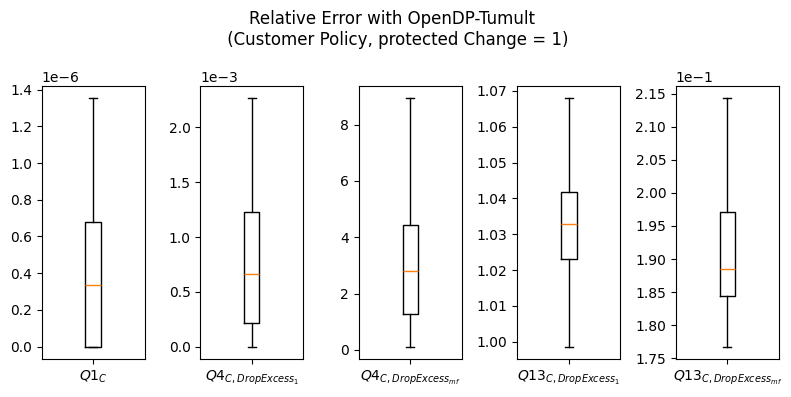

In [13]:
test_profile = "customer_policy_session_1_eps_protected_change_1_results"
tpch_query_results = calculate_all_customer_errors(test_profile)
export_relerror_all_queries(
    tpch_query_results,
    test_name=test_profile,
    output_dir=f"./output/{test_profile}"

)

plot_customer_relerror(tpch_query_results, title="Relative Error with OpenDP-Tumult \n (Customer Policy, protected Change = 1)")

Q1
Distinct runs = 50
join
qerror
+------------+------------+------+--------------+-----------------+------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|
+------------+------------+------+--------------+-----------------+------+
|           A|           F|     1|     1478494.0|        1478493.0|   1.0|
|           A|           O|     1|           1.0|              0.0|   1.0|
|           N|           F|     1|       38856.0|          38854.0|   2.0|
|           N|           O|     1|     2920374.0|        2920374.0|   0.0|
|           R|           F|     1|     1478869.0|        1478870.0|   1.0|
|           R|           O|     1|           0.0|              0.0|   0.0|
+------------+------------+------+--------------+-----------------+------+

relerror
+------------+------------+------+--------------+-----------------+------+--------------------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|            relerror|
+------------+

Q16


Distinct runs = 50
join
qerror


+--------+--------------------+------+------+---------------+------------------+------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|
+--------+--------------------+------+------+---------------+------------------+------+
|Brand#11|ECONOMY ANODIZED ...|     7|     1|           -6.0|               0.0|   6.0|
|Brand#11|ECONOMY ANODIZED ...|    12|     1|           -7.0|               8.0|  15.0|
|Brand#11|ECONOMY ANODIZED ...|    16|     1|            3.0|               0.0|   3.0|
|Brand#11|ECONOMY ANODIZED ...|    22|     1|          -19.0|               0.0|  19.0|
|Brand#11|ECONOMY ANODIZED ...|    31|     1|           30.0|               0.0|  30.0|
|Brand#11|ECONOMY ANODIZED ...|    32|     1|            1.0|               0.0|   1.0|
|Brand#11|ECONOMY ANODIZED ...|    33|     1|            0.0|               0.0|   0.0|
|Brand#11|ECONOMY ANODIZED ...|    34|     1|           -5.0|               0.0|   5.0|
|Brand#11|ECONOMY ANODIZED ...| 

+--------+--------------------+------+------+---------------+------------------+------+------------------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|          relerror|
+--------+--------------------+------+------+---------------+------------------+------+------------------+
|Brand#11|ECONOMY ANODIZED ...|     7|     1|           -6.0|               0.0|   6.0|               6.0|
|Brand#11|ECONOMY ANODIZED ...|    12|     1|           -7.0|               8.0|  15.0|             1.875|
|Brand#11|ECONOMY ANODIZED ...|    16|     1|            3.0|               0.0|   3.0|               3.0|
|Brand#11|ECONOMY ANODIZED ...|    22|     1|          -19.0|               0.0|  19.0|              19.0|
|Brand#11|ECONOMY ANODIZED ...|    31|     1|           30.0|               0.0|  30.0|              30.0|
|Brand#11|ECONOMY ANODIZED ...|    32|     1|            1.0|               0.0|   1.0|               1.0|
|Brand#11|ECONOMY ANODIZED ...|    33

Q16
Distinct runs = 40
join
qerror


+-------+------+------+------+---------------+------------------+------+
|p_brand|p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|
+-------+------+------+------+---------------+------------------+------+
+-------+------+------+------+---------------+------------------+------+

relerror


+-------+------+------+------+---------------+------------------+------+--------+
|p_brand|p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|relerror|
+-------+------+------+------+---------------+------------------+------+--------+
+-------+------+------+------+---------------+------------------+------+--------+



Mean relative error for Q1: 4.1934591506351393e-07
Mean relative error for Q4: 1.7576817066263926
Mean relative error for Q16 (DropExcess_1): 3.6753925587301586
Mean relative error for Q16 (DropExcess_mf): 149.02773256349207


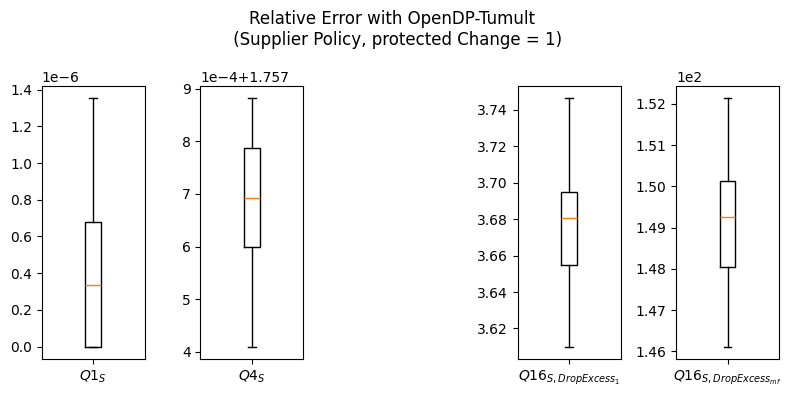

In [14]:
test_profile = "supplier_policy_session_1_eps_protected_change_1_results"
tpch_query_results = calculate_all_supplier_errors(test_profile)
export_relerror_all_queries(
    tpch_query_results,
    test_name=test_profile,
    output_dir=f"./output/{test_profile}"

)
plot_supplier_relerror(tpch_query_results, title="Relative Error with OpenDP-Tumult \n (Supplier Policy, protected Change = 1)")


Q1
Distinct runs = 50
join
qerror
+------------+------------+------+--------------+-----------------+------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|
+------------+------------+------+--------------+-----------------+------+
+------------+------------+------+--------------+-----------------+------+

relerror
+------------+------------+------+--------------+-----------------+------+--------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|relerror|
+------------+------------+------+--------------+-----------------+------+--------+
+------------+------------+------+--------------+-----------------+------+--------+

----------
+------+------------+------------+-----------------+--------------+------+--------------------+
|run_id|l_returnflag|l_linestatus|count_order_truth|count_order_dp|qerror|            relerror|
+------+------------+------------+-----------------+--------------+------+--------------------+
|    56|           A

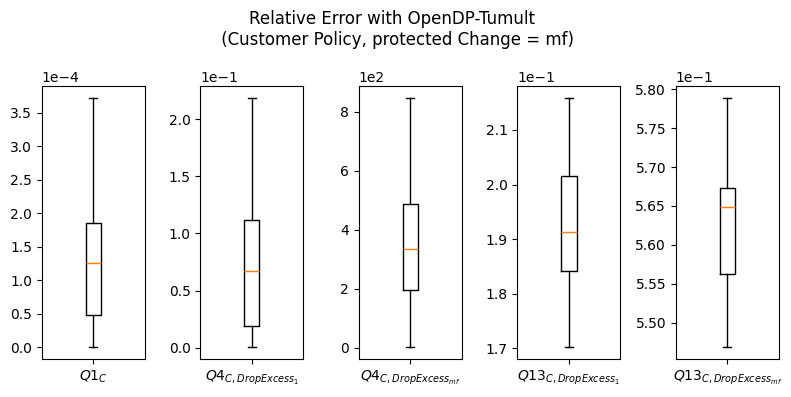

In [15]:
test_profile = "customer_policy_session_1_eps_protected_change_mf_results"
tpch_query_results = calculate_all_customer_errors(test_profile)
export_relerror_all_queries(
    tpch_query_results,
    test_name=test_profile,
    output_dir=f"./output/{test_profile}"

)
plot_customer_relerror(tpch_query_results, title="Relative Error with OpenDP-Tumult \n (Customer Policy, protected Change = mf)")

Q1
Distinct runs = 50
join
qerror
+------------+------------+------+--------------+-----------------+------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|
+------------+------------+------+--------------+-----------------+------+
|           A|           F|     1|     1478091.0|        1478493.0| 402.0|
|           A|           O|     1|          21.0|              0.0|  21.0|
|           N|           F|     1|       38588.0|          38854.0| 266.0|
|           N|           O|     1|     2920333.0|        2920374.0|  41.0|
|           R|           F|     1|     1478585.0|        1478870.0| 285.0|
|           R|           O|     1|         231.0|              0.0| 231.0|
+------------+------------+------+--------------+-----------------+------+

relerror
+------------+------------+------+--------------+-----------------+------+--------------------+
|l_returnflag|l_linestatus|run_id|count_order_dp|count_order_truth|qerror|            relerror|
+------------+

Q16


Distinct runs = 50
join
qerror


+--------+--------------------+------+------+---------------+------------------+------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|
+--------+--------------------+------+------+---------------+------------------+------+
|Brand#11|ECONOMY ANODIZED ...|     2|     1|         -295.0|               0.0| 295.0|
|Brand#11|ECONOMY ANODIZED ...|     6|     1|          541.0|               8.0| 533.0|
|Brand#11|ECONOMY ANODIZED ...|    13|     1|          -61.0|               0.0|  61.0|
|Brand#11|ECONOMY ANODIZED ...|    19|     1|          322.0|               0.0| 322.0|
|Brand#11|ECONOMY ANODIZED ...|    20|     1|          296.0|               0.0| 296.0|
|Brand#11|ECONOMY ANODIZED ...|    22|     1|         -421.0|               0.0| 421.0|
|Brand#11|ECONOMY ANODIZED ...|    29|     1|         -114.0|               0.0| 114.0|
|Brand#11|ECONOMY ANODIZED ...|    31|     1|         -112.0|               0.0| 112.0|
|Brand#11|ECONOMY ANODIZED ...| 

+--------+--------------------+------+------+---------------+------------------+------+--------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|relerror|
+--------+--------------------+------+------+---------------+------------------+------+--------+
|Brand#11|ECONOMY ANODIZED ...|     2|     1|         -295.0|               0.0| 295.0|   295.0|
|Brand#11|ECONOMY ANODIZED ...|     6|     1|          541.0|               8.0| 533.0|  66.625|
|Brand#11|ECONOMY ANODIZED ...|    13|     1|          -61.0|               0.0|  61.0|    61.0|
|Brand#11|ECONOMY ANODIZED ...|    19|     1|          322.0|               0.0| 322.0|   322.0|
|Brand#11|ECONOMY ANODIZED ...|    20|     1|          296.0|               0.0| 296.0|   296.0|
|Brand#11|ECONOMY ANODIZED ...|    22|     1|         -421.0|               0.0| 421.0|   421.0|
|Brand#11|ECONOMY ANODIZED ...|    29|     1|         -114.0|               0.0| 114.0|   114.0|
|Brand#11|ECONOMY ANODIZED ...

Q16


Distinct runs = 50
join
qerror


+--------+--------------------+------+------+---------------+------------------+------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|
+--------+--------------------+------+------+---------------+------------------+------+
|Brand#11|ECONOMY ANODIZED ...|     5|     1|         -509.0|               0.0| 509.0|
|Brand#11|ECONOMY ANODIZED ...|    15|     1|         -334.0|               0.0| 334.0|
|Brand#11|ECONOMY ANODIZED ...|    27|     1|          -22.0|               0.0|  22.0|
|Brand#11|ECONOMY ANODIZED ...|    36|     1|         -212.0|               0.0| 212.0|
|Brand#11|ECONOMY ANODIZED ...|     1|     1|        -1080.0|               0.0|1080.0|
|Brand#11|ECONOMY ANODIZED ...|     5|     1|           17.0|               0.0|  17.0|
|Brand#11|ECONOMY ANODIZED ...|     6|     1|          -20.0|              12.0|  32.0|
|Brand#11|ECONOMY ANODIZED ...|    13|     1|          -67.0|               0.0|  67.0|
|Brand#11|ECONOMY ANODIZED ...| 

+--------+--------------------+------+------+---------------+------------------+------+------------------+
| p_brand|              p_type|p_size|run_id|supplier_cnt_dp|supplier_cnt_truth|qerror|          relerror|
+--------+--------------------+------+------+---------------+------------------+------+------------------+
|Brand#11|ECONOMY ANODIZED ...|     5|     1|         -509.0|               0.0| 509.0|             509.0|
|Brand#11|ECONOMY ANODIZED ...|    15|     1|         -334.0|               0.0| 334.0|             334.0|
|Brand#11|ECONOMY ANODIZED ...|    27|     1|          -22.0|               0.0|  22.0|              22.0|
|Brand#11|ECONOMY ANODIZED ...|    36|     1|         -212.0|               0.0| 212.0|             212.0|
|Brand#11|ECONOMY ANODIZED ...|     1|     1|        -1080.0|               0.0|1080.0|            1080.0|
|Brand#11|ECONOMY ANODIZED ...|     5|     1|           17.0|               0.0|  17.0|              17.0|
|Brand#11|ECONOMY ANODIZED ...|     6

Mean relative error for Q1: 0.0004312634554238674
Mean relative error for Q4: 1.7527109684727205
Mean relative error for Q16 (DropExcess_1): 149.06610223333334
Mean relative error for Q16 (DropExcess_mf): 294.44485749365083


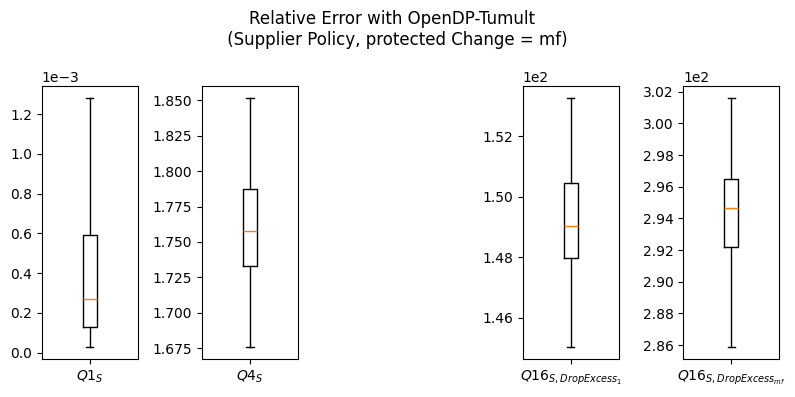

In [16]:
test_profile = "supplier_policy_session_1_eps_protected_change_mf_results"
tpch_query_results = calculate_all_supplier_errors(test_profile)
export_relerror_all_queries(
    tpch_query_results,
    test_name=test_profile,
    output_dir=f"./output/{test_profile}"

)
plot_supplier_relerror(tpch_query_results, title="Relative Error with OpenDP-Tumult \n (Supplier Policy, protected Change = mf)")


In [ ]:
test_profile = "customer_policy_session_1_eps_protected_change_add_change_id"
tpch_query_results = calculate_all_customer_errors(test_profile)
plot_customer_relerror(tpch_query_results)

***
